▶ TRAIN_0001 (Unstable) 분석 중...


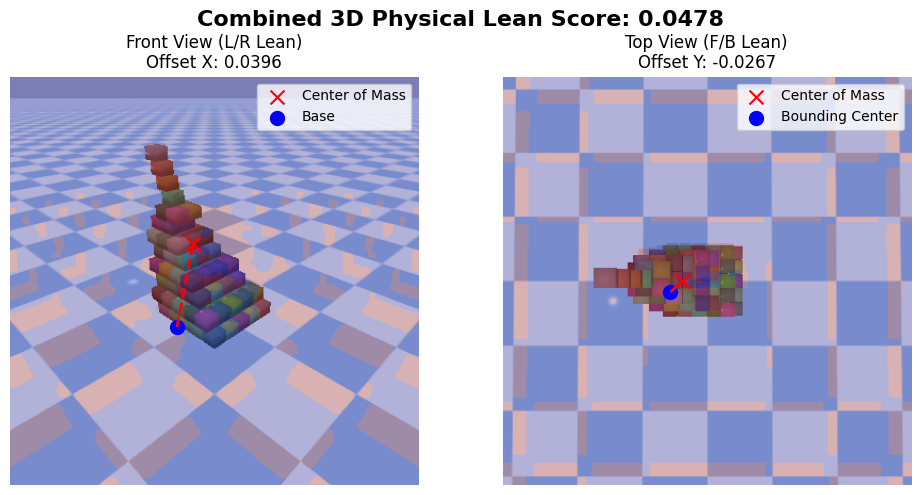

▶ TRAIN_0005 (Stable) 분석 중...


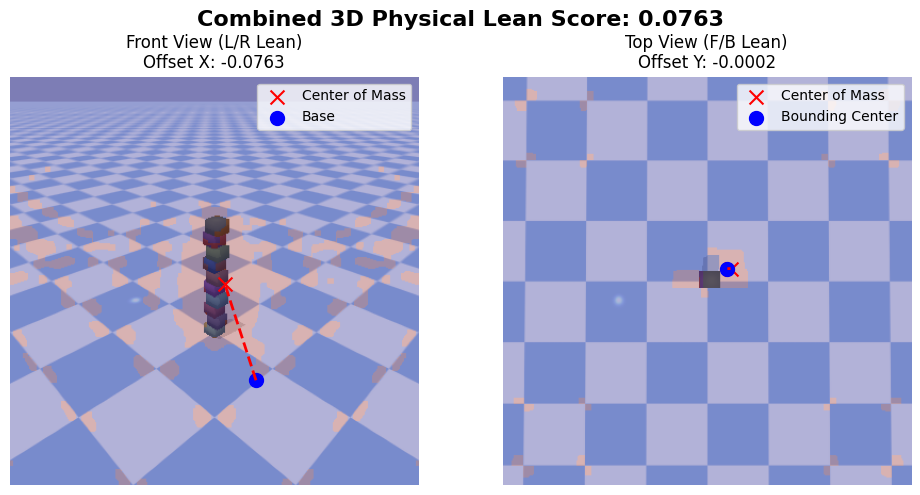

In [5]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def get_mask_from_bg(img_path, bg_img):
    """배경을 차분하여 블록 마스크를 반환하는 헬퍼 함수"""
    img = cv2.imread(img_path)
    if img is None: return None, None
    diff = cv2.absdiff(img, bg_img)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return img, mask

def calculate_interactive_physics(front_path, top_path, bg_front, bg_top, visualize=False):
    """Front와 Top을 상호작용시켜 3D 기울기 벡터를 계산합니다."""
    
    img_f, mask_f = get_mask_from_bg(front_path, bg_front)
    img_t, mask_t = get_mask_from_bg(top_path, bg_top)
    
    if img_f is None or img_t is None: return 0.0, 0.0, 0.0
    
    # ─── 1. Front View 분석 (좌우 쏠림 측정) ───
    offset_x_front = 0.0
    cx_f, cy_f, base_x_f, bottom_y_f = 0, 0, 0, 0
    contours_f, _ = cv2.findContours(mask_f, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours_f:
        c_f = max(contours_f, key=cv2.contourArea)
        M_f = cv2.moments(c_f)
        if M_f["m00"] != 0:
            cx_f = M_f["m10"] / M_f["m00"]
            cy_f = M_f["m01"] / M_f["m00"]
            c_pts_f = c_f.reshape(-1, 2)
            bottom_y_f = c_pts_f[:, 1].max()
            base_points_f = c_pts_f[c_pts_f[:, 1] >= bottom_y_f - 5]
            if len(base_points_f) > 0:
                base_x_f = np.mean(base_points_f[:, 0])
                offset_x_front = (cx_f - base_x_f) / img_f.shape[1]

    # ─── 2. Top View 분석 (앞뒤 및 좌우 쏠림 측정) ───
    offset_x_top, offset_y_top = 0.0, 0.0
    cx_t, cy_t, bbox_cx_t, bbox_cy_t = 0, 0, 0, 0
    contours_t, _ = cv2.findContours(mask_t, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours_t:
        c_t = max(contours_t, key=cv2.contourArea)
        M_t = cv2.moments(c_t)
        if M_t["m00"] != 0:
            cx_t = M_t["m10"] / M_t["m00"]
            cy_t = M_t["m01"] / M_t["m00"]
            # Top 뷰는 바운딩 박스의 중심과 무게중심의 차이로 쏠림을 측정
            x, y, w, h = cv2.boundingRect(c_t)
            bbox_cx_t = x + w / 2.0
            bbox_cy_t = y + h / 2.0
            
            offset_x_top = (cx_t - bbox_cx_t) / img_t.shape[1]
            offset_y_top = (cy_t - bbox_cy_t) / img_t.shape[0]

    # ─── 3. 상호작용 결합 (3D Lean Magnitude) ───
    # Front의 좌우 쏠림과 Top의 앞뒤 쏠림을 결합하여 최종 불안정성 크기를 도출
    combined_lean = np.sqrt(offset_x_front**2 + offset_y_top**2)

    # ─── 4. 시각화 (두 시점의 상호작용 비교) ───
    if visualize:
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        
        # Front 시각화
        axs[0].imshow(cv2.cvtColor(img_f, cv2.COLOR_BGR2RGB))
        axs[0].imshow(mask_f, cmap='jet', alpha=0.3) # 마스크 덧씌우기
        if cx_f != 0:
            axs[0].scatter(cx_f, cy_f, c='red', s=100, marker='x', label='Center of Mass')
            axs[0].scatter(base_x_f, bottom_y_f, c='blue', s=100, marker='o', label='Base')
            axs[0].plot([base_x_f, cx_f], [bottom_y_f, cy_f], 'r--', linewidth=2)
        axs[0].set_title(f"Front View (L/R Lean)\nOffset X: {offset_x_front:.4f}")
        axs[0].legend(loc='upper right')
        axs[0].axis('off')

        # Top 시각화
        axs[1].imshow(cv2.cvtColor(img_t, cv2.COLOR_BGR2RGB))
        axs[1].imshow(mask_t, cmap='jet', alpha=0.3)
        if cx_t != 0:
            axs[1].scatter(cx_t, cy_t, c='red', s=100, marker='x', label='Center of Mass')
            axs[1].scatter(bbox_cx_t, bbox_cy_t, c='blue', s=100, marker='o', label='Bounding Center')
            axs[1].plot([bbox_cx_t, cx_t], [bbox_cy_t, cy_t], 'r--', linewidth=2)
        axs[1].set_title(f"Top View (F/B Lean)\nOffset Y: {offset_y_top:.4f}")
        axs[1].legend(loc='upper right')
        axs[1].axis('off')

        plt.suptitle(f"Combined 3D Physical Lean Score: {combined_lean:.4f}", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return offset_x_front, offset_x_top, offset_y_top, combined_lean

# ─── 실행 테스트 ───
# 앞서 구한 bg_front, bg_top 변수가 메모리에 있다고 가정합니다.
train_folder = './data/train'

# Unstable 샘플 테스트 (두 뷰의 결합 결과 확인)
print("▶ TRAIN_0001 (Unstable) 분석 중...")
_ = calculate_interactive_physics(
    os.path.join(train_folder, 'TRAIN_0001', 'front.png'),
    os.path.join(train_folder, 'TRAIN_0001', 'top.png'),
    bg_front, bg_top, visualize=True
)

# Stable 샘플 테스트
print("▶ TRAIN_0005 (Stable) 분석 중...")
_ = calculate_interactive_physics(
    os.path.join(train_folder, 'TRAIN_0005', 'front.png'),
    os.path.join(train_folder, 'TRAIN_0005', 'top.png'),
    bg_front, bg_top, visualize=True
)

정적 배경 생성 중 (체스판 소멸 중)...


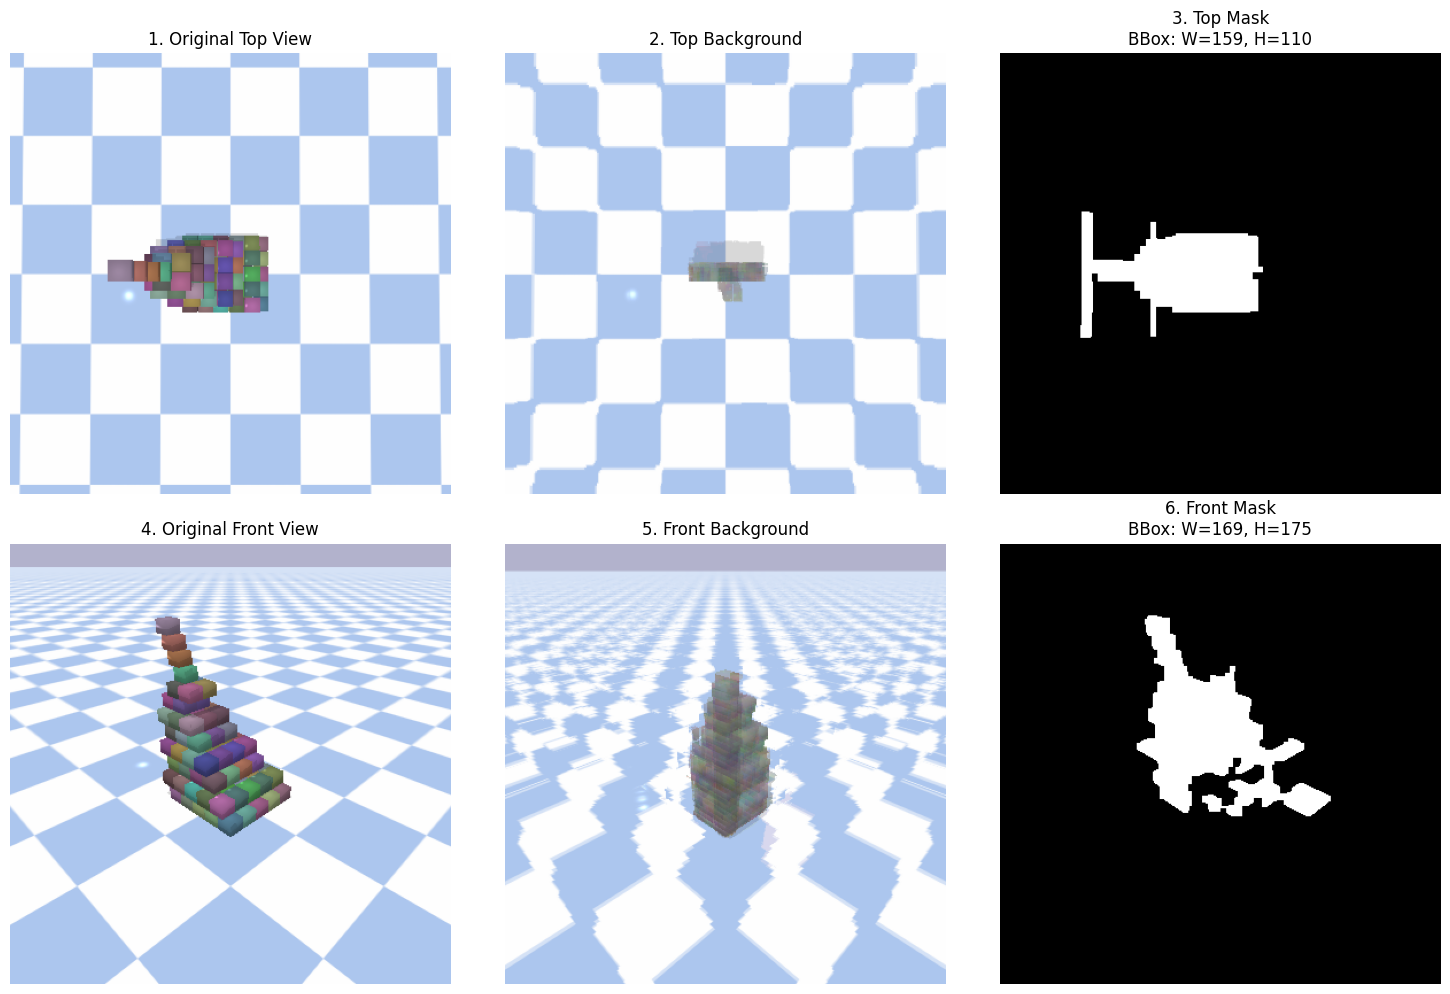

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

def get_static_bg(image_folder, view_type='front', sample_size=30):
    """지정된 폴더에서 이미지를 샘플링하여 체스판 배경만 추출합니다."""
    search_path = os.path.join(image_folder, '*', f'{view_type}.png')
    img_paths = glob.glob(search_path)
    np.random.shuffle(img_paths)
    
    images = [cv2.imread(p) for p in img_paths[:sample_size] if cv2.imread(p) is not None]
    if not images: return None
    return np.median(np.array(images), axis=0).astype(np.uint8)

def extract_perfect_mask(img, bg_img, threshold=30):
    """배경 차분을 통해 체스판과 하늘을 완벽히 날리고 블록 마스크만 반환합니다."""
    # 1. 배경 빼기
    diff = cv2.absdiff(img, bg_img)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    
    # 2. 이진화 (차이가 threshold 이상인 부분만 255)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    
    # 3. 노이즈 제거 (모폴로지 연산)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # 4. 가장 큰 윤곽선(블록)만 남기기
    final_mask = np.zeros_like(mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        cv2.drawContours(final_mask, [c], -1, 255, -1)
        # Bounding Box 정보 추출
        x, y, w, h = cv2.boundingRect(c)
        return final_mask, (x, y, w, h)
    return final_mask, (0, 0, 0, 0)

def flawless_segmentation_test(front_path, top_path, train_folder):
    img_f = cv2.imread(front_path)
    img_t = cv2.imread(top_path)
    
    # 1. 배경 이미지 생성 (실제 학습 시에는 미리 만들어두고 불러오는 것을 권장)
    print("정적 배경 생성 중 (체스판 소멸 중)...")
    bg_f = get_static_bg(train_folder, 'front')
    bg_t = get_static_bg(train_folder, 'top')
    
    # 2. 마스크 및 Bounding Box 추출
    mask_t, bbox_t = extract_perfect_mask(img_t, bg_t, threshold=25)
    mask_f, bbox_f = extract_perfect_mask(img_f, bg_f, threshold=25)
    
    # 3. 시각화
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    
    # Top View 시각화
    axs[0, 0].imshow(cv2.cvtColor(img_t, cv2.COLOR_BGR2RGB))
    axs[0, 0].set_title("1. Original Top View")
    axs[0, 1].imshow(cv2.cvtColor(bg_t, cv2.COLOR_BGR2RGB))
    axs[0, 1].set_title("2. Top Background")
    axs[0, 2].imshow(mask_t, cmap='gray')
    axs[0, 2].set_title(f"3. Top Mask\nBBox: W={bbox_t[2]}, H={bbox_t[3]}")
    
    # Front View 시각화
    axs[1, 0].imshow(cv2.cvtColor(img_f, cv2.COLOR_BGR2RGB))
    axs[1, 0].set_title("4. Original Front View")
    axs[1, 1].imshow(cv2.cvtColor(bg_f, cv2.COLOR_BGR2RGB))
    axs[1, 1].set_title("5. Front Background")
    axs[1, 2].imshow(mask_f, cmap='gray')
    axs[1, 2].set_title(f"6. Front Mask\nBBox: W={bbox_f[2]}, H={bbox_f[3]}")
    
    for ax in axs.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- 실행 부분 ---
train_folder = './data/train'
sample_id = 'TRAIN_0001'
flawless_segmentation_test(
    os.path.join(train_folder, sample_id, 'front.png'),
    os.path.join(train_folder, sample_id, 'top.png'),
    train_folder
)

c:\Users\user\anaconda3\envs\a\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|########################################| 176M/176M [00:00<00:00, 174GB/s]


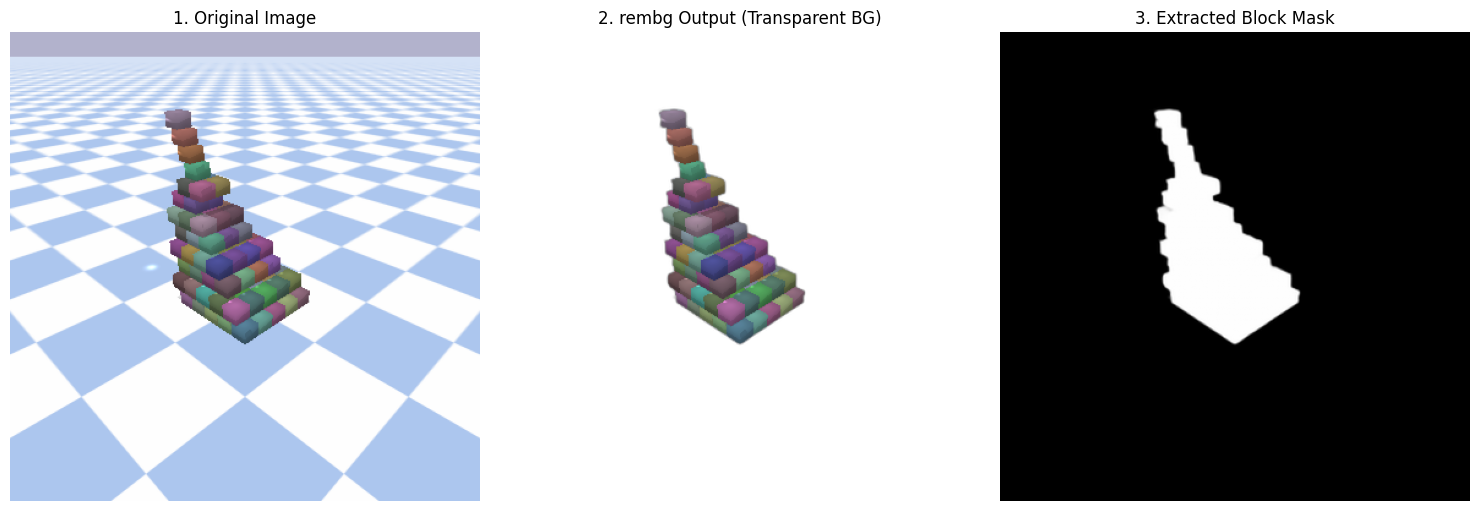

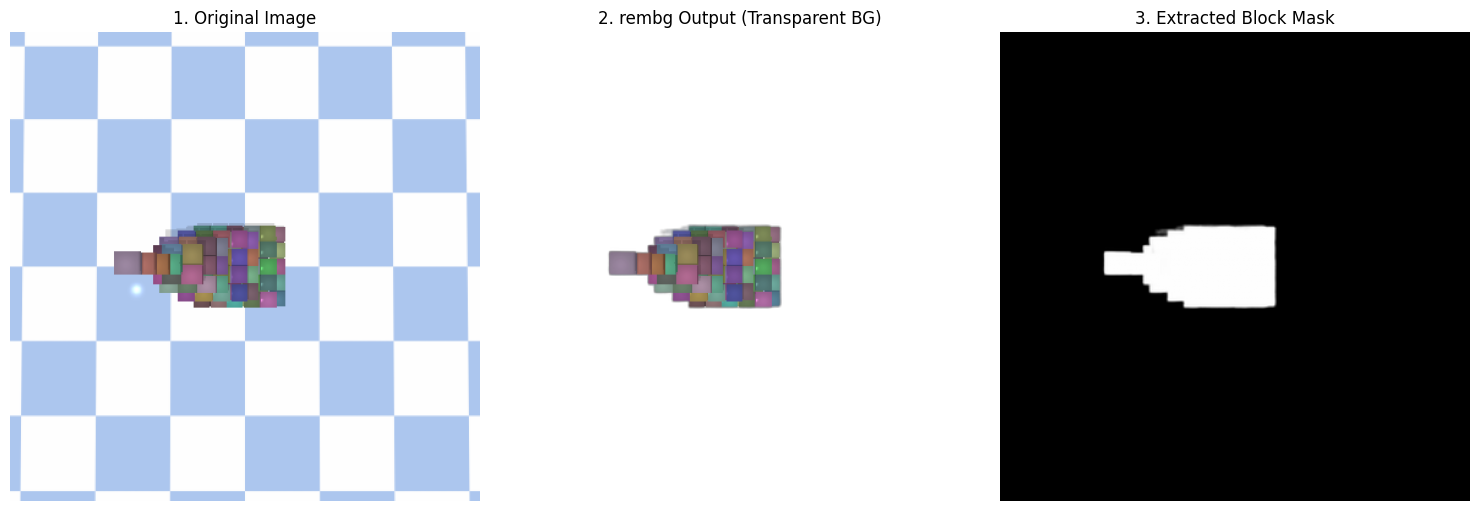

In [2]:
import cv2
import matplotlib.pyplot as plt
from rembg import remove
from PIL import Image
import numpy as np

def test_rembg_segmentation(img_path):
    # 1. 이미지 로드
    input_img = Image.open(img_path)
    
    # 2. rembg를 통한 딥러닝 기반 배경 제거 (U^2-Net 동작)
    output_img = remove(input_img)
    
    # 3. 결과 마스크 추출 (Alpha 채널 활용)
    output_np = np.array(output_img)
    mask = output_np[:, :, 3] # 투명도가 0이 아닌 부분을 마스크로 사용
    
    # 4. 시각화
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(input_img)
    axs[0].set_title("1. Original Image")
    axs[0].axis('off')
    
    axs[1].imshow(output_img)
    axs[1].set_title("2. rembg Output (Transparent BG)")
    axs[1].axis('off')
    
    axs[2].imshow(mask, cmap='gray')
    axs[2].set_title("3. Extracted Block Mask")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Front, Top 뷰 각각 테스트
test_rembg_segmentation('./data/train/TRAIN_0001/front.png')
test_rembg_segmentation('./data/train/TRAIN_0001/top.png')

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from rembg import remove
from tqdm.auto import tqdm

def get_clean_mask(img_path):
    """rembg를 사용하여 원본 이미지에서 객체(블록)의 마스크만 정밀하게 추출합니다."""
    try:
        input_img = Image.open(img_path).convert("RGB")
        output_img = remove(input_img)
        
        # RGBA에서 Alpha 채널(투명도)만 가져와 이진 마스크로 변환
        mask = np.array(output_img)[:, :, 3]
        _, binary_mask = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        return binary_mask
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

def extract_front_physics(mask):
    """Front 뷰 마스크에서 좌우 쏠림(L/R Lean)과 세장비(Slenderness)를 추출합니다."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return 0.0, 0.0
    
    c = max(contours, key=cv2.contourArea)
    M = cv2.moments(c)
    if M["m00"] == 0: return 0.0, 0.0
    
    # 전체 무게중심
    cx = M["m10"] / M["m00"]
    
    # 바운딩 박스를 통해 높이 구하기
    x, y, w, h = cv2.boundingRect(c)
    
    # 기저면(Base) 계산: 가장 아래쪽(Y가 큰) 픽셀들
    c_pts = c.reshape(-1, 2)
    bottom_y = c_pts[:, 1].max()
    base_points = c_pts[c_pts[:, 1] >= bottom_y - 5] # 바닥에서 5픽셀 이내
    
    if len(base_points) == 0:
        base_x = cx
        base_w = w
    else:
        base_x = np.mean(base_points[:, 0])
        base_w = base_points[:, 0].max() - base_points[:, 0].min()
    
    # 0 나누기 방지
    base_w = max(base_w, 1.0)
    
    # 1. 좌우 쏠림값 (이미지 너비로 정규화)
    lr_lean = (cx - base_x) / mask.shape[1]
    
    # 2. 세장비 (구조물 높이 / 기저면 폭) -> 값이 클수록 불안정
    slenderness = h / base_w
    
    return lr_lean, slenderness

def extract_top_physics(mask):
    """Top 뷰 마스크에서 앞뒤 쏠림(F/B Lean)을 추출합니다."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return 0.0
    
    c = max(contours, key=cv2.contourArea)
    M = cv2.moments(c)
    if M["m00"] == 0: return 0.0
    
    # 전체 무게중심
    cy = M["m01"] / M["m00"]
    
    # 직교 투영에서의 바운딩 박스 중심 (이상적인 수직 적재 시 무게중심과 일치해야 함)
    x, y, w, h = cv2.boundingRect(c)
    bbox_cy = y + h / 2.0
    
    # 3. 앞뒤 쏠림값 (이미지 높이로 정규화)
    fb_lean = (cy - bbox_cy) / mask.shape[0]
    
    return fb_lean

# ─── 메인 실행 루프 ───
if __name__ == "__main__":
    train_df = pd.read_csv('./data/train.csv')
    train_folder = './data/train'
    
    # 결과를 담을 리스트
    lr_leans, fb_leans = [], []
    slenderness_ratios, combined_leans = [], []
    
    print("🚀 Physics Pseudo-Label 생성 시작 (rembg 기반)")
    # 약 1,000개 데이터 * 2뷰 = 2,000장 처리 (환경에 따라 5~15분 소요 예상)
    for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
        sample_id = str(row['id'])
        front_path = os.path.join(train_folder, sample_id, 'front.png')
        top_path = os.path.join(train_folder, sample_id, 'top.png')
        
        # 마스크 추출
        mask_f = get_clean_mask(front_path)
        mask_t = get_clean_mask(top_path)
        
        # 마스크가 정상적으로 추출되었을 때 물리 지표 계산
        if mask_f is not None and mask_t is not None:
            lr_lean, slenderness = extract_front_physics(mask_f)
            fb_lean = extract_top_physics(mask_t)
        else:
            lr_lean, slenderness, fb_lean = 0.0, 0.0, 0.0
            
        # 4. 3D 쏠림 벡터 크기 (Magnitude) 계산
        combined_lean = np.sqrt(lr_lean**2 + fb_lean**2)
        
        # 스케일이 너무 작은 값들 보정 (딥러닝 Loss 계산 시 Vanishing 방지)
        lr_leans.append(lr_lean * 10.0)
        fb_leans.append(fb_lean * 10.0)
        slenderness_ratios.append(slenderness)
        combined_leans.append(combined_lean * 10.0)

    # DataFrame에 새로운 Target 컬럼 추가
    train_df['lr_lean'] = lr_leans
    train_df['fb_lean'] = fb_leans
    train_df['slenderness'] = slenderness_ratios
    train_df['combined_lean'] = combined_leans
    
    # 최종 Physics CSV 저장
    save_path = './data/train_physics.csv'
    train_df.to_csv(save_path, index=False)
    print(f"\n✅ 물리적 정답지 추출 완료! 저장 위치: {save_path}")
    print(train_df.head())

🚀 Physics Pseudo-Label 생성 시작 (rembg 기반)


100%|██████████| 1000/1000 [22:49<00:00,  1.37s/it]


✅ 물리적 정답지 추출 완료! 저장 위치: ./data/train_physics.csv
           id     label   lr_lean   fb_lean  slenderness  combined_lean
0  TRAIN_0001  unstable -0.457861 -0.032559    12.125000       0.459017
1  TRAIN_0002  unstable  0.643888  0.024724    11.461538       0.644362
2  TRAIN_0003  unstable  0.220226 -0.036685    10.833333       0.223261
3  TRAIN_0004  unstable  0.966097  0.002646     4.235294       0.966100
4  TRAIN_0005    stable  0.049201 -0.007481     6.105263       0.049766


=== [물리 지표별 라벨 기반 통계 요약] ===
           lr_lean                                 fb_lean            \
              mean       std       min       max      mean       std   
label                                                                  
stable   -0.109865  0.184511 -0.498965  0.092758 -0.023996  0.088762   
unstable -0.043295  0.708074 -2.698004  2.096162 -0.002731  0.159351   

                             slenderness                                \
               min       max        mean       std      min        max   
label                                                                    
stable   -0.505815  0.236163   10.623072  3.174625  5.80000  22.750000   
unstable -0.754787  0.766663   10.670757  3.968879  0.42623  26.571429   

         combined_lean                                
                  mean       std       min       max  
label                                                 
stable        0.151599  0.177668  0.001838  0.627537  
unstable      0.559

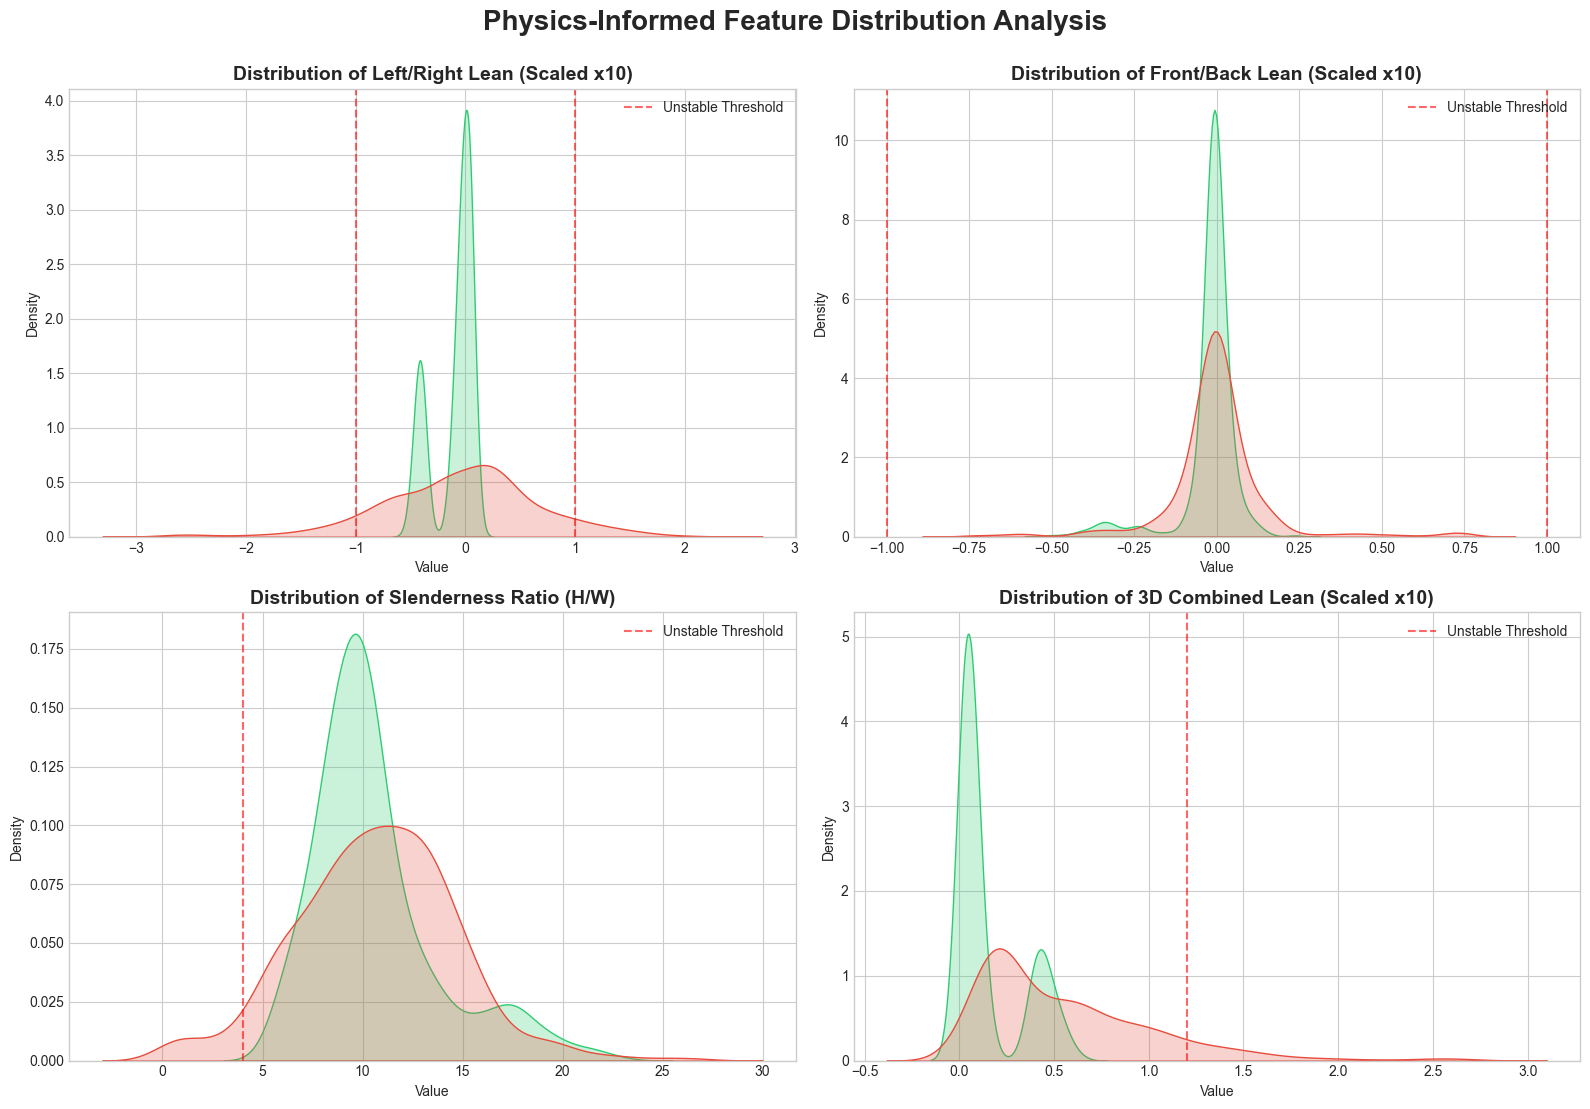

=== [물리 지표의 변별력 분석 (Unstable/Stable Ratio)] ===
[lr_lean] Unstable Mean is 3.91x higher than Stable Mean
[fb_lean] Unstable Mean is 1.96x higher than Stable Mean
[slenderness] Unstable Mean is 1.00x higher than Stable Mean
[combined_lean] Unstable Mean is 3.69x higher than Stable Mean


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 로드
df = pd.read_csv('./data/train_physics.csv')

# 2. 분석할 지표 리스트 및 기대 임계치(Threshold) 설정
metrics = {
    'lr_lean': {'title': 'Left/Right Lean (Scaled x10)', 'thresh': 1.0},
    'fb_lean': {'title': 'Front/Back Lean (Scaled x10)', 'thresh': 1.0},
    'slenderness': {'title': 'Slenderness Ratio (H/W)', 'thresh': 4.0},
    'combined_lean': {'title': '3D Combined Lean (Scaled x10)', 'thresh': 1.2}
}

# 3. 통계적 요약 테이블 출력
print("=== [물리 지표별 라벨 기반 통계 요약] ===")
summary = df.groupby('label')[list(metrics.keys())].agg(['mean', 'std', 'min', 'max'])
print(summary)
print("\n" + "="*40 + "\n")

# 4. 시각화 (2x2 Subplots)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, info) in enumerate(metrics.items()):
    # KDE Plot (분포도)
    sns.kdeplot(data=df, x=col, hue='label', fill=True, common_norm=False, 
                palette={'stable': '#2ecc71', 'unstable': '#e74c3c'}, ax=axes[i])
    
    # 기대 임계치 가이드라인 (Unstable이 시작될 것으로 예상되는 지점)
    if col in ['lr_lean', 'fb_lean']:
        # 좌우/앞뒤는 절대값이 중요하므로 양쪽 표시
        axes[i].axvline(x=info['thresh'], color='red', linestyle='--', alpha=0.6, label='Unstable Threshold')
        axes[i].axvline(x=-info['thresh'], color='red', linestyle='--', alpha=0.6)
    else:
        # 세장비와 통합 쏠림은 클수록 위험하므로 우측 표시
        axes[i].axvline(x=info['thresh'], color='red', linestyle='--', alpha=0.6, label='Unstable Threshold')
    
    axes[i].set_title(f"Distribution of {info['title']}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("Physics-Informed Feature Distribution Analysis", fontsize=20, y=0.95, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('physics_analysis.png', dpi=300)
plt.show()

# 5. 변별력 수치화 (Mean Difference Ratio)
print("=== [물리 지표의 변별력 분석 (Unstable/Stable Ratio)] ===")
for col in metrics.keys():
    stable_mean = df[df['label']=='stable'][col].abs().mean()
    unstable_mean = df[df['label']=='unstable'][col].abs().mean()
    ratio = unstable_mean / (stable_mean + 1e-9)
    print(f"[{col}] Unstable Mean is {ratio:.2f}x higher than Stable Mean")